# S11 — TCB Spare-Parts Demand Segmentation (Phase 1)

Classifies every TCB item by its **demand pattern** so each part can be routed to the
right stocking method (per [PRD v2 §4](../docs/PRD_Technical_BOM_Review_Assistant_v2.md)
and the [ML implementation plan](../docs/ML_Implementation_Plan_TCB.md)).

**Method — Syntetos–Boylan–Croston (SBC):**
- **ADI** = average interval between demands (periods ÷ demand occurrences) → how *rare*.
- **CV²** = squared coefficient of variation of the non-zero demand sizes → how *lumpy*.
- Cutoffs: `ADI = 1.32`, `CV² = 0.49`.

| Segment | ADI | CV² | Routing |
|---|---|---|---|
| Smooth | <1.32 | <0.49 | SBA |
| Erratic | <1.32 | ≥0.49 | SBA |
| Intermittent | ≥1.32 | <0.49 | SBA / TSB |
| Lumpy | ≥1.32 | ≥0.49 | SBA + bootstrap |
| Dormant | present, never consumed | hard-rule / keep-alive policy |
| No-history | <2 snapshots | feature-based cold-start model |

**Input:** `analysis/output/s10_tcb_panel_long.csv`  ·  **Monthly demand bucket:** `last_30_day_cnsmptn_qty`.
Missing months stay missing (never zero-filled); a present month with blank consumption counts as 0.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast.models import CrostonClassic, CrostonSBA, TSB

# Locate the s10 panel regardless of whether the notebook runs from analysis/ or repo root.
CANDIDATES = [Path("output/s10_tcb_panel_long.csv"),
              Path("analysis/output/s10_tcb_panel_long.csv")]
SRC = next((p for p in CANDIDATES if p.exists()), CANDIDATES[0])
OUT = SRC.parent

DEMAND_COL = "last_30_day_cnsmptn_qty"   # monthly demand bucket
ADI_CUT, CV2_CUT = 1.32, 0.49            # Syntetos-Boylan-Croston cutoffs
TSB_ALPHA_D, TSB_ALPHA_P = 0.1, 0.1      # TSB smoothing (demand size, demand probability)

panel = pd.read_csv(SRC, encoding="utf-8-sig").sort_values(["item_id", "month_index"])
print(f"pandas {pd.__version__} | statsforecast estimators loaded")
print(f"panel: {len(panel):,} item-months  |  {panel['item_id'].nunique():,} items  "
      f"|  {panel['snapshot_month'].nunique()} snapshots")
panel[["snapshot_month", "item_id", DEMAND_COL, "machine_type"]].head()


c:\Users\jialelim\OneDrive - Intel Corporation\Desktop\Project 1 - BOM review Chatbot\BOM-Assistant-Agentic-Workflow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 2.3.3 | statsforecast estimators loaded
panel: 9,424 item-months  |  3,060 items  |  8 snapshots


,snapshot_month,item_id,last_30_day_cnsmptn_qty,machine_type
0,2024-08,500028887,50,"Asymtek S932;Asymtek S922;Generic;ASYMTEK,M-20..."
1,2024-10,500028887,100,"ASYMTEK,M-FMCMIR-IN;Asymtek S932;Asymtek S912;..."
2,2026-01,500035612,0,Generic;Asymtek S922;Asymtek S932;DP Besi 300M...
3,2024-09,500035614,0,"Asymtek S932;Generic;ASYMTEK,M-FMCMIR-IN;ASYMT..."
4,2024-12,500035614,0,"Asymtek S932;ASYMTEK,M-FMCMIR-IN;Generic;ASYMT..."


## 1. Metrics & estimators

Demand-rate estimates use the **`statsforecast`** library (`CrostonClassic`, `CrostonSBA`,
`TSB`) — validated implementations rather than hand-rolled ones. `adi` / `cv2` are computed
inline (simple demand statistics) and drive the segment classification.


In [6]:
# Reusable statsforecast intermittent-demand estimators (validated implementations).
_SBA = CrostonSBA()
_CROSTON = CrostonClassic()
_TSB = TSB(alpha_d=TSB_ALPHA_D, alpha_p=TSB_ALPHA_P)


def _rate(model, demand):
    """One-step point demand rate from a statsforecast intermittent-demand model.

    Returns NaN when the estimator cannot handle the (often very short, gappy)
    series — e.g. TSB needs a longer history than some items provide."""
    d = np.asarray(demand, dtype=float)
    if d.size == 0 or d.sum() == 0:      # all-zero -> no demand signal
        return 0.0
    if d.size < 2:                       # single observation -> library is degenerate
        return float(d[0])
    try:
        return float(model.forecast(y=d, h=1)["mean"][0])
    except (ValueError, ZeroDivisionError):
        return float("nan")


def sba_rate(demand):
    return _rate(_SBA, demand)


def tsb_rate(demand):
    return _rate(_TSB, demand)


def adi(demand):
    """Average demand interval = periods / number of non-zero periods."""
    d = np.asarray(demand, float)
    nz = int((d > 0).sum())
    return len(d) / nz if nz else np.inf


def cv2(demand):
    """Squared coefficient of variation of the non-zero demand sizes."""
    sizes = np.asarray(demand, float)
    sizes = sizes[sizes > 0]
    if sizes.size < 2:
        return 0.0
    return (sizes.std(ddof=1) / sizes.mean()) ** 2


def classify(n_periods, n_nonzero, a, c):
    if n_periods < 2:
        return "No-history"
    if n_nonzero == 0:
        return "Dormant"
    if a < ADI_CUT and c < CV2_CUT:
        return "Smooth"
    if a < ADI_CUT and c >= CV2_CUT:
        return "Erratic"
    if a >= ADI_CUT and c < CV2_CUT:
        return "Intermittent"
    return "Lumpy"


## 2. Segment every item

Build each item's ordered monthly demand series, compute ADI / CV² / SBA, assign a segment,
and save to `output/s11_segmentation.csv`.


In [7]:
# latest snapshot per item for static attributes
latest = panel.groupby("item_id").tail(1).set_index("item_id")

rows = []
for item_id, g in panel.groupby("item_id"):
    d = g[DEMAND_COL].fillna(0).to_numpy(dtype=float)
    n, nz = len(d), int((d > 0).sum())
    a, c = adi(d), cv2(d)
    rows.append({
        "item_id": item_id,
        "item_desc": latest.at[item_id, "item_desc"],
        "machine_type": latest.at[item_id, "machine_type"],
        "n_months": n,
        "n_nonzero": nz,
        "adi": round(a, 3) if np.isfinite(a) else np.nan,
        "cv2": round(c, 3),
        "mean_monthly_demand": round(float(d.mean()), 3),
        "sba_monthly_rate": round(sba_rate(d), 4),
        "tsb_monthly_rate": round(tsb_rate(d), 4),
        "segment": classify(n, nz, a, c),
    })

seg = pd.DataFrame(rows)
seg.to_csv(OUT / "s11_segmentation.csv", index=False, encoding="utf-8-sig")
print(f"segmented {len(seg):,} items -> {OUT / 's11_segmentation.csv'}")
seg.sort_values("n_nonzero", ascending=False).head(10)


segmented 3,060 items -> output\s11_segmentation.csv


,item_id,item_desc,machine_type,n_months,n_nonzero,adi,cv2,mean_monthly_demand,sba_monthly_rate,tsb_monthly_rate,segment
49,500175684,"FERRULES NYLON 1/4""TUBE 10SETS",Generic;Asymtek S932,6,4,1.500,0.807,3.5,2.7621,2.6225,Lumpy
2413,500727761,RECALIBRATION SINGLE GLASS DIE 25X25,GENERIC;KnS TCX3,4,4,1.000,0.296,3.0,1.6359,1.7220,Smooth
2195,500688607,NOZZLE HEAD 11 POTENTIAL FREE MOUNTED,"GENERIC;PLASMATREAT, APPJ_PTU1612",5,3,1.667,0.000,1.2,1.0000,0.5258,Intermittent
2281,500699384,"AIRFILTER,LOWPRESSURE,DROP,MINI,PLEA",KnS TCX3;GENERIC,6,3,2.000,0.000,1.0,0.9548,0.5112,Intermittent
2598,500771779,"PLACE TOOL 33,SiSiC501,30.38x24.83x1.2s",KnS TCX3;GENERIC,5,3,1.667,0.000,0.6,0.7917,0.8290,Intermittent
32,500122237,SPECTRUM HEATED PURGE CUP ASSEMBLY,Asymtek S932;Generic;Asymtek S922;Asymtek S902,4,2,2.000,0.000,0.5,0.8636,0.8190,Intermittent
3,500041276,"FITTING, QUICK DISCONNECT FEM.","Asymtek S912;Asymtek S932;ASYMTEK,M-2000;ASYMT...",4,2,2.000,0.500,1.0,2.4182,2.2932,Lumpy
0,500028887,LOWER BEARING SEAL DV-8000,"ASYMTEK,M-FMCMIR-IN;Asymtek S932;Asymtek S912;...",2,2,1.000,0.222,75.0,52.2500,55.0000,Smooth
34,500122956,NEEDLE HEATER DJ-2200,Generic;Asymtek S932,6,2,3.000,0.222,0.5,0.9500,0.2632,Intermittent
1535,500237420,SILICONE SUCTION CUP 2.5MM,"ASM-Pacific,Phoenix;HDMx x30;ASM-Pacific,Fireb...",4,2,2.000,0.222,37.5,45.1250,17.1950,Intermittent


## 3. How the parts distribute


In [8]:
ORDER = ["Smooth", "Erratic", "Intermittent", "Lumpy", "Dormant", "No-history"]
by_seg = seg["segment"].value_counts().reindex(ORDER).fillna(0).astype(int)

active_n = int(by_seg[["Smooth", "Erratic", "Intermittent", "Lumpy"]].sum())
summary = pd.DataFrame({
    "items": by_seg,
    "share_%": (by_seg / len(seg) * 100).round(1),
})
print(summary.to_string())
print(f"\nActive (SBC-classifiable): {active_n:,}"
      f"   Dormant: {by_seg['Dormant']:,}   No-history: {by_seg['No-history']:,}")
summary


              items  share_%
segment                     
Smooth            2      0.1
Erratic           0      0.0
Intermittent    106      3.5
Lumpy             2      0.1
Dormant        2690     87.9
No-history      260      8.5

Active (SBC-classifiable): 110   Dormant: 2,690   No-history: 260


,items,share_%
segment,,
Smooth,2,0.1
Erratic,0,0.0
Intermittent,106,3.5
Lumpy,2,0.1
Dormant,2690,87.9
No-history,260,8.5


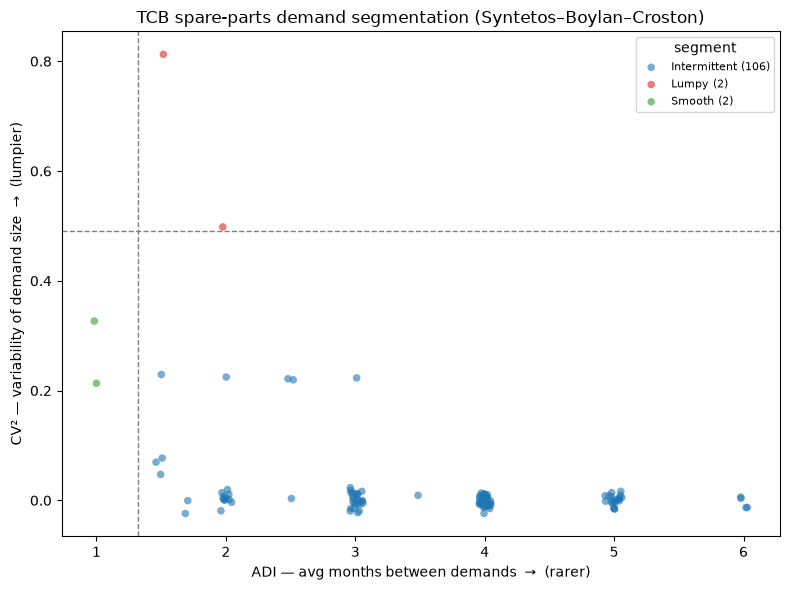

In [9]:
# --- SBC quadrant scatter: ADI vs CV² (active items only) ---
COLORS = {"Smooth": "#2ca02c", "Erratic": "#ff7f0e",
          "Intermittent": "#1f77b4", "Lumpy": "#d62728"}
active = seg[seg["segment"].isin(COLORS)].copy()
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8, 6))
for name, grp in active.groupby("segment"):
    ax.scatter(grp["adi"] + rng.normal(0, 0.03, len(grp)),      # jitter (ADI is discrete)
               grp["cv2"] + rng.normal(0, 0.01, len(grp)),
               s=30, alpha=0.6, color=COLORS[name], edgecolor="none",
               label=f"{name} ({len(grp)})")
ax.axvline(ADI_CUT, color="grey", ls="--", lw=1)
ax.axhline(CV2_CUT, color="grey", ls="--", lw=1)
ax.set_xlabel("ADI — avg months between demands  →  (rarer)")
ax.set_ylabel("CV² — variability of demand size  →  (lumpier)")
ax.set_title("TCB spare-parts demand segmentation (Syntetos–Boylan–Croston)")
ax.legend(title="segment", fontsize=8)
plt.tight_layout()
plt.show()


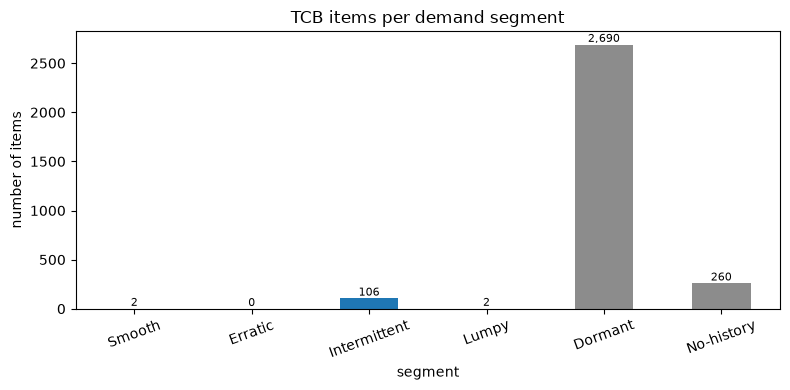

In [10]:
# --- item counts per segment ---
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [COLORS.get(s, "#8c8c8c") for s in ORDER]
by_seg.plot(kind="bar", ax=ax, color=bar_colors)
ax.set_ylabel("number of items")
ax.set_title("TCB items per demand segment")
for i, v in enumerate(by_seg.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


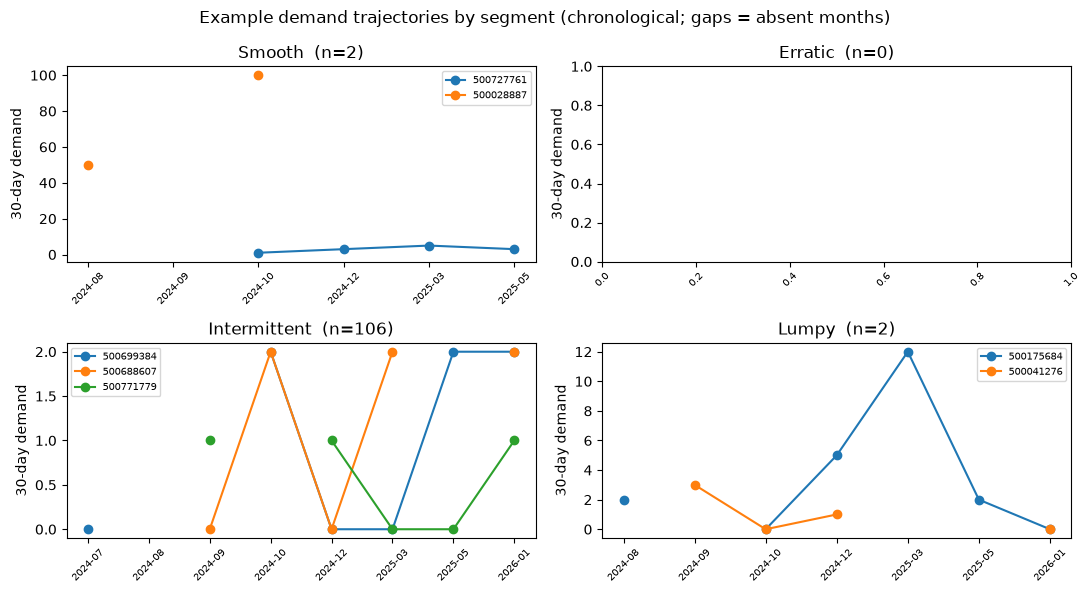

In [11]:
# --- example demand series for the busiest items in each active segment ---
months_sorted = (panel.drop_duplicates("snapshot_ym")
                 .sort_values("month_index")["snapshot_month"].tolist())

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, q in zip(axes.ravel(), ["Smooth", "Erratic", "Intermittent", "Lumpy"]):
    picks = seg[seg["segment"] == q].sort_values("n_nonzero", ascending=False).head(3)
    for iid in picks["item_id"]:
        s = (panel[panel["item_id"] == iid]
             .set_index("snapshot_month")[DEMAND_COL].reindex(months_sorted))  # gaps stay NaN
        ax.plot(months_sorted, s.to_numpy(dtype=float), marker="o", label=str(iid))
    ax.set_title(f"{q}  (n={int((seg['segment'] == q).sum())})")
    ax.set_ylabel("30-day demand")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    if len(picks):
        ax.legend(fontsize=7)
fig.suptitle("Example demand trajectories by segment (chronological; gaps = absent months)")
plt.tight_layout()
plt.show()


## 4. Read-out & next step

- **Dormant** dominates — most TCB parts never consume within a 90/30-day window. These are **not** forecast; they go to the **hard-rule / keep-alive** policy (insurance stock for critical machines — the recom = 0 trap).
- **Active** parts (Smooth / Erratic / Intermittent / Lumpy) are the ones SBA/TSB will forecast; **Lumpy** is the hardest and gets a bootstrap cross-check.
- **No-history** parts route to the feature-based cold-start model.

**Caveat:** with only ~8 irregular snapshots (most items have 3), ADI and CV² are coarse — treat the segmentation as directional, and re-run it on every new BOM (it is recomputed, not frozen).

**Output:** `analysis/output/s11_segmentation.csv` (feeds Phase 2 — SBA rate → NegBin lead-time demand → `new_min/rop/max`).
